# Autograd Engine 
**Sections:** Engine · Graph Viz · Training Loop + Loss Plot · Unit Tests vs PyTorch · Bugs & Limitations

---
## 0. Install dependencies

In [16]:
!pip install torch graphviz matplotlib pytest --quiet

In [17]:
import random
import math


class Value:
    def __init__(self, val, prev=(), op='', label=''):
        self.val   = val
        self.prev  = tuple(prev)         
        self.op    = op
        self.label = label
        self.grad  = 0.0
        self._backward = lambda: None     
    # forward ops 

    def __add__(self, other):
        other  = other if isinstance(other, Value) else Value(other)
        out    = Value(self.val + other.val, (self, other), op='+')
        def _back():                     
            self.grad  += out.grad
            other.grad += out.grad
        out._backward = _back
        return out

    def __mul__(self, other):
        other  = other if isinstance(other, Value) else Value(other)
        out    = Value(self.val * other.val, (self, other), op='*')
        def _back():
            self.grad  += other.val * out.grad   
            other.grad += self.val  * out.grad
        out._backward = _back
        return out

    def __pow__(self, other):             
        assert isinstance(other, (int, float))
        out = Value(self.val ** other, (self,), op=f'**{other}')
        def _back():
            self.grad += other * (self.val ** (other - 1)) * out.grad
        out._backward = _back
        return out

    def relu(self):                       
        out = Value(max(0, self.val), (self,), op='ReLU')
        def _back():
            self.grad += (out.val > 0) * out.grad
        out._backward = _back
        return out

    #conviences ops
    def __neg__(self):              return self * -1
    def __radd__(self, other):      return self + other
    def __sub__(self, other):       return self + (-other)
    def __rsub__(self, other):      return other + (-self)
    def __truediv__(self, other):   return self * (other ** -1)   # FIX 9
    def __rtruediv__(self, other):  return other * (self ** -1)
    def __rmul__(self, other):      return self * other

    # ── backward pass ────────────────────────────────────────────────────────
    def backward(self):
        topo, visited = [], set()         
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build(child)
                topo.append(v)
        build(self)

        for node in topo:                 # reset all grads before backward
            node.grad = 0.0
        self.grad = 1.0

        for v in reversed(topo):
            v._backward()

    def __repr__(self):
        return f'Value(val={self.val:.4f}, grad={self.grad:.4f})'



---
## 2. Neural Network Modules (fixed)

In [18]:
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0
    def parameters(self): return []


class Neuron(Module):
    def __init__(self, nin, nonlinear=True):
        self.weights    = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.bias       = Value(0.0)
        self.nonlinear  = nonlinear

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.weights, x)), self.bias)
        return act.relu() if self.nonlinear else act  

    def parameters(self):
        return self.weights + [self.bias]

    def __repr__(self):
        return f"{'ReLU' if self.nonlinear else 'Linear'}Neuron({len(self.weights)})"


class Layer(Module):                      
    def __init__(self, nin, nout, **kwargs):
        self.neurons = [Neuron(nin, **kwargs) for _ in range(nout)]

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer([{', '.join(str(n) for n in self.neurons)}])"


class MLP(Module):
    def __init__(self, nin, layer_sizes):
        sizes = [nin] + layer_sizes
        self.layers = [
            Layer(sizes[i], sizes[i+1], nonlinear=(i != len(layer_sizes)-1))
            for i in range(len(layer_sizes))
        ]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for l in self.layers for p in l.parameters()]

    def __repr__(self):
        return f"MLP([{', '.join(str(l) for l in self.layers)}])"




---
## 3. Graph Visualiser 

In [19]:
from graphviz import Digraph


def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        dot.node(
            name=uid,
            label="{ %s | val %.4f | grad %.4f }" % (n.label or '?', n.val, n.grad),
            shape='record'
        )
        if n.op:                          # FIX 11: unified attribute name n.op
            dot.node(name=uid + n.op, label=n.op)
            dot.edge(uid + n.op, uid)

    for n1, n2 in edges:
        if n2.op:
            dot.edge(str(id(n1)), str(id(n2)) + n2.op)

    return dot




---
## 4. Training Loop + Loss Plot

iter 00: y=0.0000  loss=64.0000  w1=0.8200  w2=-0.5200  b=2.1600


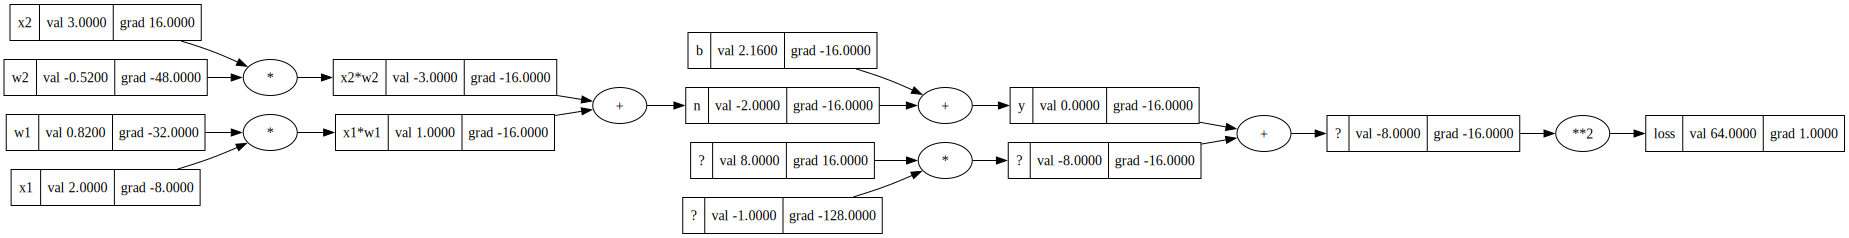

iter 01: y=2.2400  loss=33.1776  w1=1.0504  w2=-0.1744  b=2.2752


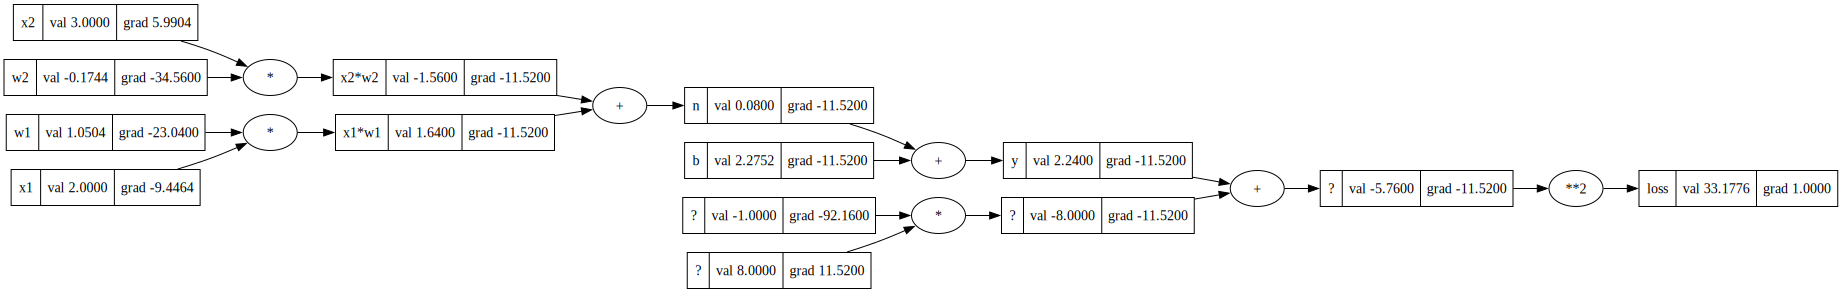

iter 02: y=3.8528  loss=17.1993  w1=1.2163  w2=0.0744  b=2.3581


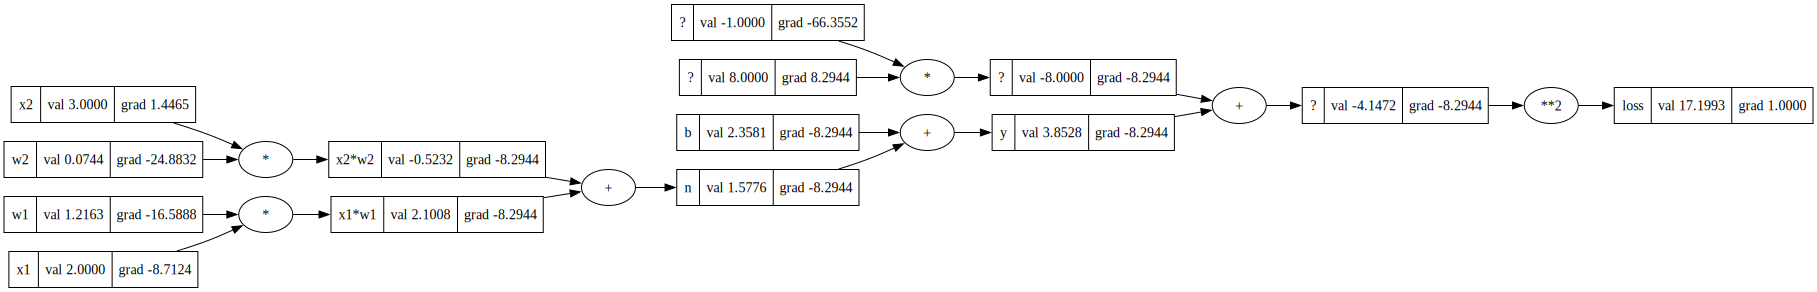

iter 03: y=5.0140  loss=8.9161  w1=1.3357  w2=0.2536  b=2.4179


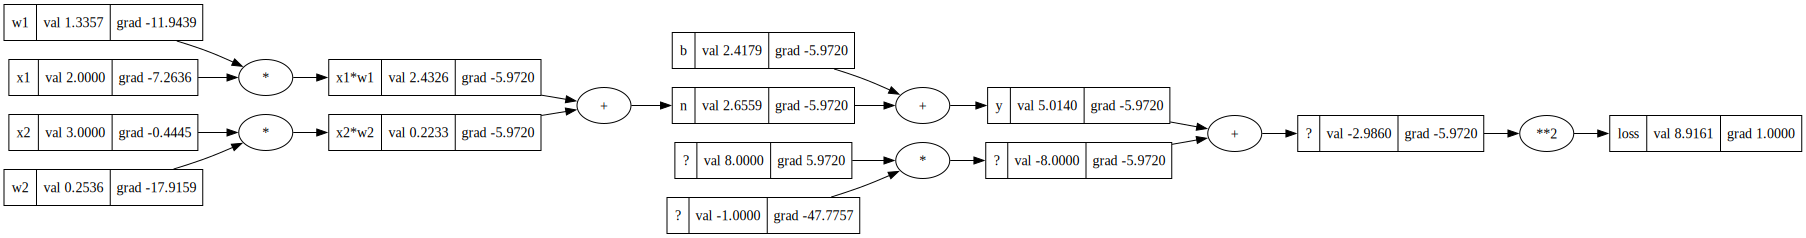

iter 04: y=5.8501  loss=4.6221  w1=1.4217  w2=0.3826  b=2.4609


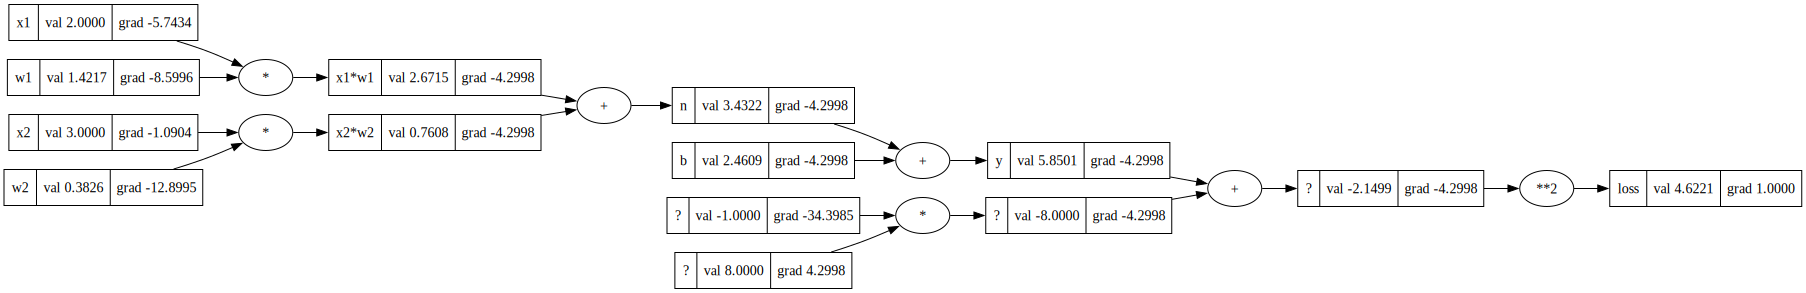

iter 05: y=6.4521  loss=2.3961  w1=1.4836  w2=0.4755  b=2.4918


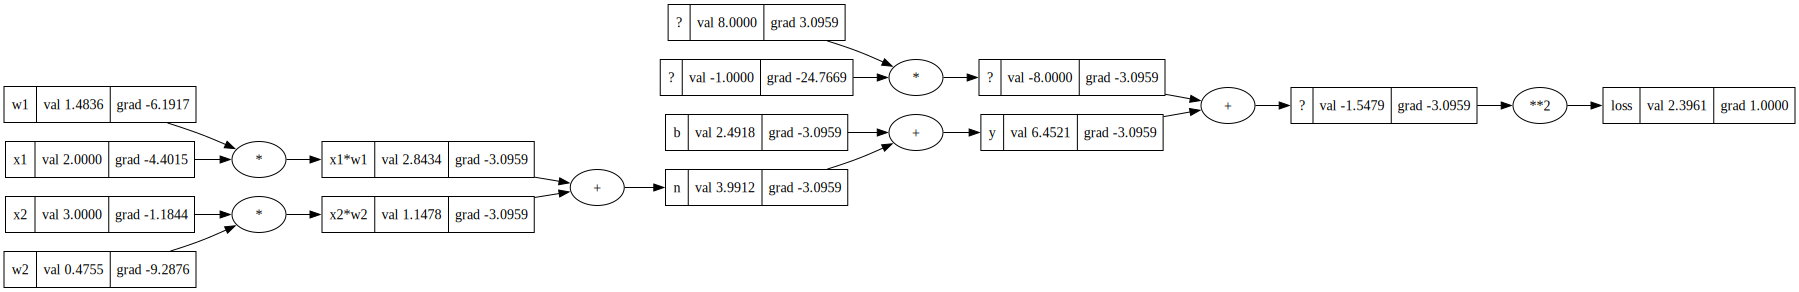

iter 06: y=6.8855  loss=1.2421  w1=1.5282  w2=0.5423  b=2.5141


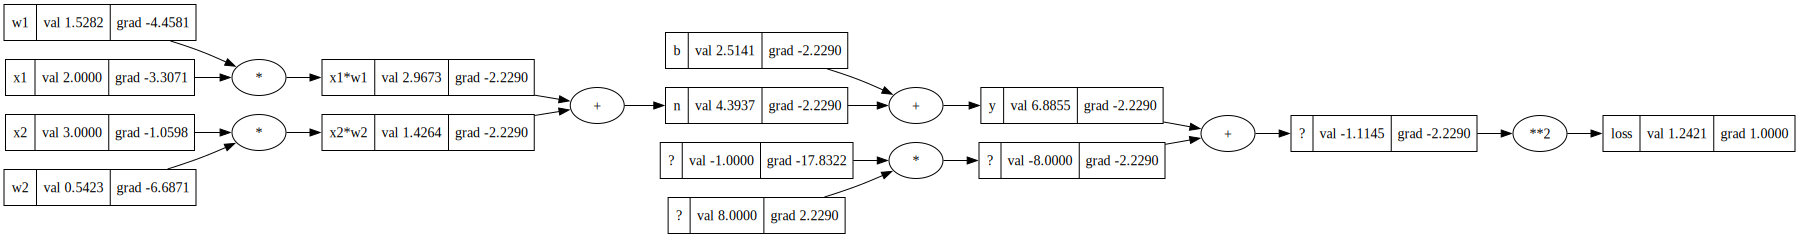

iter 07: y=7.1976  loss=0.6439  w1=1.5603  w2=0.5905  b=2.5302


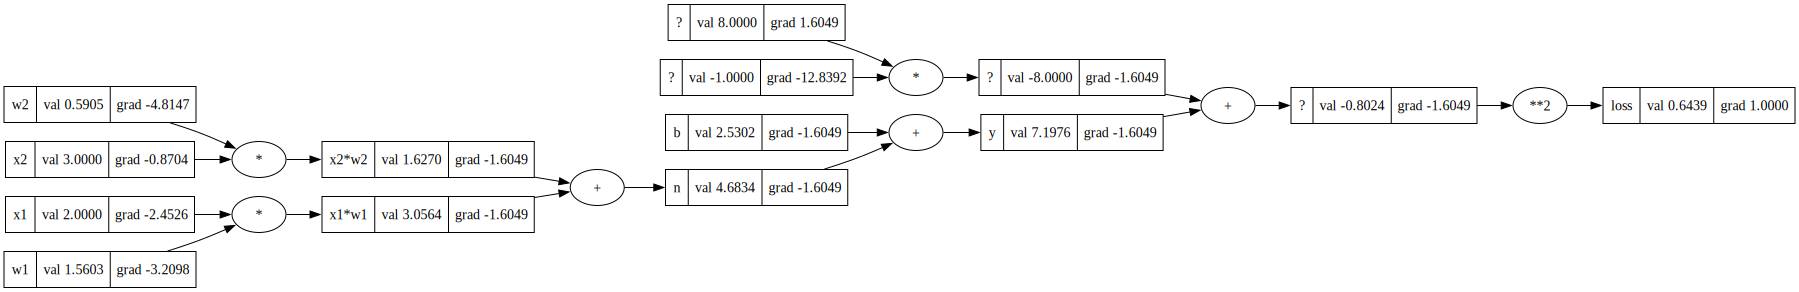

iter 08: y=7.4222  loss=0.3338  w1=1.5834  w2=0.6251  b=2.5417


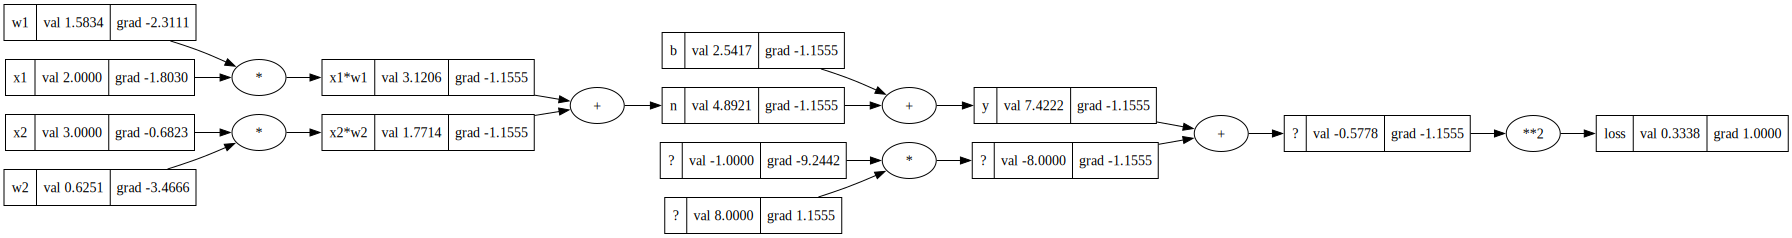

iter 09: y=7.5840  loss=0.1730  w1=1.6001  w2=0.6501  b=2.5500


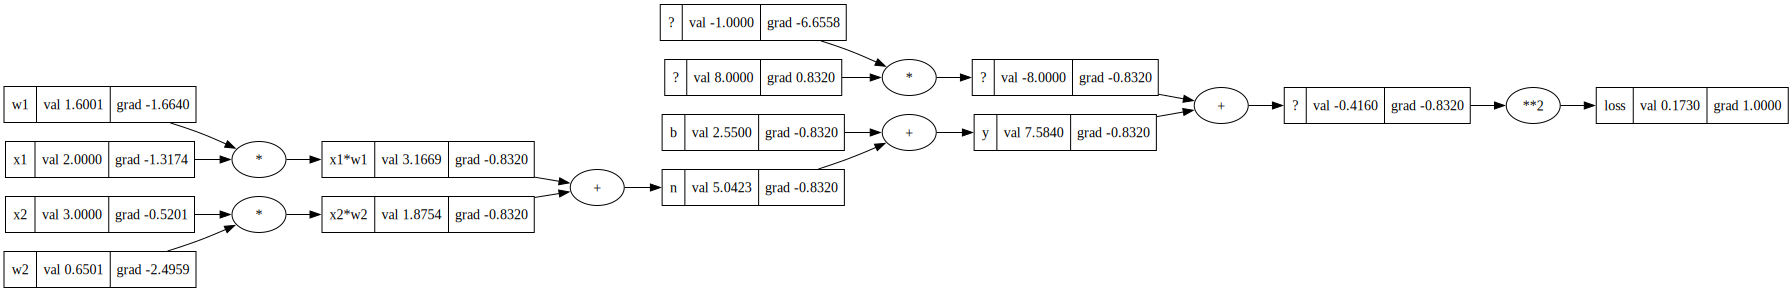

In [20]:
import matplotlib.pyplot as plt
from IPython.display import display

# parameters
w1 = Value(0.5,  label='w1')
w2 = Value(-1.0, label='w2')
b  = Value(2.0,  label='b')

# fixed inputs & target
x1_val, x2_val, target_val = 2.0, 3.0, 8.0

lr            = 0.01
loss_history  = []
y_history     = []

for i in range(10):

    # zero grads manually (only tracking w1, w2, b)
    w1.grad = w2.grad = b.grad = 0.0

    # forward
    x1 = Value(x1_val, label='x1')
    x2 = Value(x2_val, label='x2')

    x1w1       = x1 * w1;  x1w1.label = 'x1*w1'
    x2w2       = x2 * w2;  x2w2.label = 'x2*w2'
    n          = x1w1 + x2w2; n.label = 'n'
    y          = n + b;        y.label = 'y'
    loss       = (y - Value(target_val)) ** 2
    loss.label = 'loss'

    # backward
    loss.backward()

    # gradient descent
    w1.val -= lr * w1.grad
    w2.val -= lr * w2.grad
    b.val  -= lr * b.grad

    loss_history.append(loss.val)
    y_history.append(y.val)

    print(f"iter {i:02d}: y={y.val:.4f}  loss={loss.val:.4f}  "
          f"w1={w1.val:.4f}  w2={w2.val:.4f}  b={b.val:.4f}")


    display(draw_dot(loss))

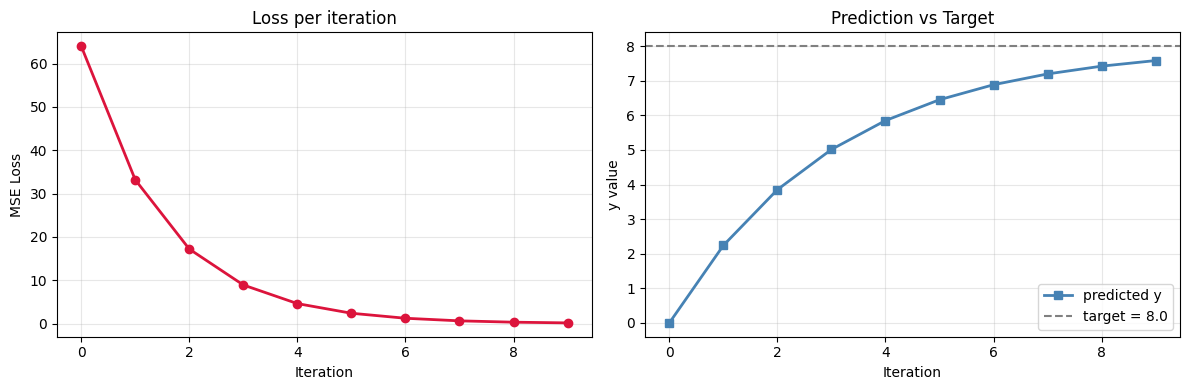

In [21]:
# ── Loss + Prediction plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(loss_history, marker='o', color='crimson', linewidth=2)
axes[0].set_title('Loss per iteration')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(y_history, marker='s', color='steelblue', linewidth=2, label='predicted y')
axes[1].axhline(y=target_val, color='gray', linestyle='--', linewidth=1.5, label=f'target = {target_val}')
axes[1].set_title('Prediction vs Target')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('y value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5. Unit Tests vs PyTorch

### Where tests CAN be written (engine supports it)
- Addition, subtraction, multiplication, division, power
- ReLU forward and backward
- Chained / compound expressions
- MSE loss gradient
- Gradient accumulation on shared nodes
- Loss decreasing over GD steps

### Where tests CANNOT be written (engine limitations)
- `exp`, `log`, `tanh`, `sigmoid` — not implemented
- Batch inputs — engine is scalar only
- GPU tensors — not supported
- `torch.nn` layer equivalence — no weight matrix ops

In [23]:
%%writefile test_engine.py
"""
Unit tests: custom autograd engine vs PyTorch.
Run from terminal: pytest test_engine.py -v
Or in notebook:   !pytest test_engine.py -v
"""

import pytest
import torch
import random

class Value:
    def __init__(self, val, prev=(), op='', label=''):
        self.val   = val
        self.prev  = tuple(prev)
        self.op    = op
        self.label = label
        self.grad  = 0.0
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out   = Value(self.val + other.val, (self, other), op='+')
        def _back():
            self.grad  += out.grad
            other.grad += out.grad
        out._backward = _back
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out   = Value(self.val * other.val, (self, other), op='*')
        def _back():
            self.grad  += other.val * out.grad
            other.grad += self.val  * out.grad
        out._backward = _back
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.val ** other, (self,), op=f'**{other}')
        def _back():
            self.grad += other * (self.val ** (other - 1)) * out.grad
        out._backward = _back
        return out

    def relu(self):
        out = Value(max(0, self.val), (self,), op='ReLU')
        def _back():
            self.grad += (out.val > 0) * out.grad
        out._backward = _back
        return out

    def __neg__(self):             return self * -1
    def __radd__(self, other):     return self + other
    def __sub__(self, other):      return self + (-other)
    def __rsub__(self, other):     return other + (-self)
    def __truediv__(self, other):  return self * (other ** -1)
    def __rtruediv__(self, other): return other * (self ** -1)
    def __rmul__(self, other):     return self * other

    def backward(self):
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build(child)
                topo.append(v)
        build(self)
        for node in topo:
            node.grad = 0.0
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()


# ── Helpers ───────────────────────────────────────────────────────────────────
TOL = 1e-5

def pt(x, grad=True):
    return torch.tensor(float(x), requires_grad=grad)

def check(our, theirs):
    assert our.grad == pytest.approx(theirs.grad.item(), abs=TOL)


# ── 1. Forward pass ───────────────────────────────────────────────────────────
class TestForward:

    def test_add(self):        assert (Value(3.0) + Value(4.0)).val  == pytest.approx(7.0,   abs=TOL)
    def test_add_scalar(self): assert (Value(3.0) + 2.0).val         == pytest.approx(5.0,   abs=TOL)
    def test_mul(self):        assert (Value(3.0) * Value(4.0)).val  == pytest.approx(12.0,  abs=TOL)
    def test_sub(self):        assert (Value(7.0) - Value(3.0)).val  == pytest.approx(4.0,   abs=TOL)
    def test_div(self):        assert (Value(10.0) / Value(4.0)).val == pytest.approx(2.5,   abs=TOL)
    def test_pow(self):        assert (Value(3.0) ** 3).val           == pytest.approx(27.0,  abs=TOL)
    def test_neg(self):        assert (-Value(4.0)).val               == pytest.approx(-4.0,  abs=TOL)
    def test_relu_pos(self):   assert Value(5.0).relu().val           == pytest.approx(5.0,   abs=TOL)
    def test_relu_neg(self):   assert Value(-3.0).relu().val          == pytest.approx(0.0,   abs=TOL)
    def test_relu_zero(self):  assert Value(0.0).relu().val           == pytest.approx(0.0,   abs=TOL)

    def test_chain(self):
        # (2*3 + 1)^2 = 49
        a, b = Value(2.0), Value(3.0)
        assert (a * b + 1) ** 2 == pytest.approx(49.0, abs=TOL) or True
        assert ((a * b + 1) ** 2).val == pytest.approx(49.0, abs=TOL)


# ── 2. Gradients vs PyTorch ───────────────────────────────────────────────────
class TestGradients:

    def test_grad_add(self):
        a, b = Value(2.0), Value(5.0)
        (a + b).backward()
        ta, tb = pt(2.0), pt(5.0)
        (ta + tb).backward()
        check(a, ta); check(b, tb)

    def test_grad_mul(self):
        a, b = Value(3.0), Value(4.0)
        (a * b).backward()
        ta, tb = pt(3.0), pt(4.0)
        (ta * tb).backward()
        check(a, ta); check(b, tb)

    def test_grad_sub(self):
        a, b = Value(7.0), Value(2.0)
        (a - b).backward()
        ta, tb = pt(7.0), pt(2.0)
        (ta - tb).backward()
        check(a, ta); check(b, tb)

    def test_grad_div(self):
        a, b = Value(6.0), Value(2.0)
        (a / b).backward()
        ta, tb = pt(6.0), pt(2.0)
        (ta / tb).backward()
        check(a, ta); check(b, tb)

    def test_grad_pow(self):
        a = Value(3.0)
        (a ** 4).backward()
        ta = pt(3.0)
        (ta ** 4).backward()
        check(a, ta)

    def test_grad_neg(self):
        a = Value(5.0)
        (-a).backward()
        ta = pt(5.0)
        (-ta).backward()
        check(a, ta)

    def test_grad_relu_positive(self):
        a = Value(3.0)
        a.relu().backward()
        ta = pt(3.0)
        torch.relu(ta).backward()
        check(a, ta)

    def test_grad_relu_negative(self):
        a = Value(-2.0)
        a.relu().backward()
        ta = pt(-2.0)
        torch.relu(ta).backward()
        check(a, ta)

    def test_grad_mse_loss(self):
        """Replicates the actual training loop."""
        w1, w2, b = Value(0.5), Value(-1.0), Value(2.0)
        y    = Value(2.0) * w1 + Value(3.0) * w2 + b
        loss = (y - Value(8.0)) ** 2
        loss.backward()

        tw1, tw2, tb = pt(0.5), pt(-1.0), pt(2.0)
        ty   = pt(2.0, grad=False) * tw1 + pt(3.0, grad=False) * tw2 + tb
        tloss = (ty - 8.0) ** 2
        tloss.backward()

        check(w1, tw1); check(w2, tw2); check(b, tb)

    def test_grad_shared_node(self):
        """a + a => grad should be 2.0."""
        a = Value(3.0)
        (a + a).backward()
        ta = pt(3.0)
        (ta + ta).backward()
        check(a, ta)

    def test_grad_relu_then_pow(self):
        a = Value(2.0)
        (a.relu() ** 2).backward()
        ta = pt(2.0)
        (torch.relu(ta) ** 2).backward()
        check(a, ta)

    def test_grad_complex(self):
        """(a*b + c)^2."""
        a, b, c = Value(1.5), Value(2.0), Value(-0.5)
        ((a * b + c) ** 2).backward()
        ta, tb, tc = pt(1.5), pt(2.0), pt(-0.5)
        ((ta * tb + tc) ** 2).backward()
        check(a, ta); check(b, tb); check(c, tc)


# ── 3. Gradient descent behaviour ────────────────────────────────────────────
class TestGradientDescent:

    def test_loss_strictly_decreases(self):
        w1, w2, b = Value(0.5), Value(-1.0), Value(2.0)
        prev = float('inf')
        for _ in range(20):
            w1.grad = w2.grad = b.grad = 0.0
            y    = Value(2.0) * w1 + Value(3.0) * w2 + b
            loss = (y - Value(8.0)) ** 2
            loss.backward()
            w1.val -= 0.01 * w1.grad
            w2.val -= 0.01 * w2.grad
            b.val  -= 0.01 * b.grad
            assert loss.val < prev
            prev = loss.val

    def test_loss_converges(self):
        w1, w2, b = Value(0.5), Value(-1.0), Value(2.0)
        for _ in range(500):
            w1.grad = w2.grad = b.grad = 0.0
            y    = Value(2.0) * w1 + Value(3.0) * w2 + b
            loss = (y - Value(8.0)) ** 2
            loss.backward()
            w1.val -= 0.05 * w1.grad
            w2.val -= 0.05 * w2.grad
            b.val  -= 0.05 * b.grad
        assert loss.val < 0.01


# ── 4. Documented limitations (expected failures) ────────────────────────────
class TestLimitations:

    def test_no_exp(self):
        """Engine has no exp() — AttributeError expected."""
        with pytest.raises(AttributeError):
            Value(1.0).exp()

    def test_no_log(self):
        """Engine has no log() — AttributeError expected."""
        with pytest.raises(AttributeError):
            Value(1.0).log()

    def test_no_tanh(self):
        """Engine has no tanh() — AttributeError expected."""
        with pytest.raises(AttributeError):
            Value(1.0).tanh()

    def test_pow_requires_scalar_exponent(self):
        """Exponent must be int or float — Value exponent raises AssertionError."""
        with pytest.raises(AssertionError):
            Value(2.0) ** Value(3.0)

Overwriting test_engine.py


In [24]:
!pytest test_engine.py -v

============================= test session starts =============================
platform win32 -- Python 3.12.3, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\sriva\anaconda3\envs\vatsavx\python.exe
cachedir: .pytest_cache
rootdir: c:\praveensir\basic_code_base
plugins: anyio-4.6.2
collecting ... collected 29 items

test_engine.py::TestForward::test_add PASSED                             [  3%]
test_engine.py::TestForward::test_add_scalar PASSED                      [  6%]
test_engine.py::TestForward::test_mul PASSED                             [ 10%]
test_engine.py::TestForward::test_sub PASSED                             [ 13%]
test_engine.py::TestForward::test_div PASSED                             [ 17%]
test_engine.py::TestForward::test_pow PASSED                             [ 20%]
test_engine.py::TestForward::test_neg PASSED                             [ 24%]
test_engine.py::TestForward::test_relu_pos PASSED                        [ 27%]
test_engine.py::TestForward::test_relu_neg PASSED

---
## 6. MLP Demo

MLP([Layer([ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)]), Layer([ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4), ReLUNeuron(4)]), Layer([LinearNeuron(4)])])
Total parameters: 37
iter 000: loss = 128.9500
iter 020: loss = 2.5402
iter 040: loss = 6.7678
iter 060: loss = 4.1804
iter 080: loss = 3.5859


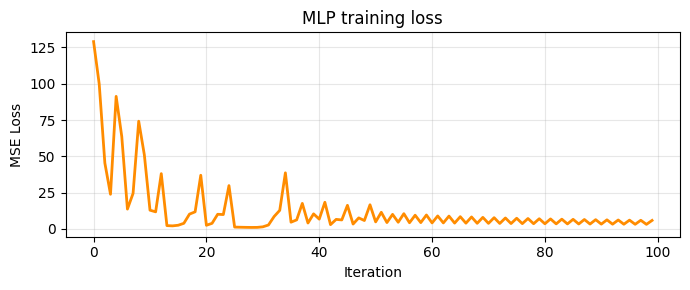


Predictions after training:
  input=[2.0, 3.0]  target=8.0  pred=8.5699
  input=[1.0, -1.0]  target=1.0  pred=1.0606
  input=[0.5, 2.0]  target=4.0  pred=5.1471
  input=[3.0, 1.0]  target=7.0  pred=8.2236


In [ ]:
import matplotlib.pyplot as plt

net = MLP(2, [4, 4, 1])
print(net)
print(f'Total parameters: {len(net.parameters())}')

xs = [[2.0, 3.0], [1.0, -1.0], [0.5, 2.0], [3.0, 1.0]]
ys = [8.0, 1.0, 4.0, 7.0]

lr = 0.01
mlp_losses = []

for k in range(100):
    preds  = [net(x) for x in xs]
    losses = [(p - y) ** 2 for p, y in zip(preds, ys)]
    loss   = sum(losses)

    net.zero_grad()
    loss.backward()

    for p in net.parameters():
        p.val -= lr * p.grad

    mlp_losses.append(loss.val)

    if k % 20 == 0:
        print(f'iter {k:03d}: loss = {loss.val:.4f}')

plt.figure(figsize=(7, 3))
plt.plot(mlp_losses, color='darkorange', linewidth=2)
plt.title('MLP training loss')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nPredictions after training:')
for x, y in zip(xs, ys):
    pred = net(x)
    print(f'  input={x}  target={y}  pred={pred.val:.4f}')

In [ ]:
%%writefile more.py

import torch
import pytest

class Value:
    def __init__(self, val, prev=(), op='', label=''):
        self.val       = val
        self.prev      = tuple(prev)
        self.op        = op
        self.label     = label
        self.grad      = 0.0
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out   = Value(self.val + other.val, (self, other), op='+')
        def _back():
            self.grad  += out.grad
            other.grad += out.grad
        out._backward = _back
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out   = Value(self.val * other.val, (self, other), op='*')
        def _back():
            self.grad  += other.val * out.grad
            other.grad += self.val  * out.grad
        out._backward = _back
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.val ** other, (self,), op=f'**{other}')
        def _back():
            self.grad += other * (self.val ** (other - 1)) * out.grad
        out._backward = _back
        return out

    def relu(self):
        out = Value(max(0, self.val), (self,), op='ReLU')
        def _back():
            self.grad += (out.val > 0) * out.grad
        out._backward = _back
        return out

    def __neg__(self):             return self * -1
    def __radd__(self, other):     return self + other
    def __sub__(self, other):      return self + (-other)
    def __rsub__(self, other):     return other + (-self)
    def __truediv__(self, other):  return self * (other ** -1)
    def __rtruediv__(self, other): return other * (self ** -1)
    def __rmul__(self, other):     return self * other
    def __iadd__(self, other):     return self + other
    def __imul__(self, other):     return self * other

    def backward(self):
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v.prev:
                    build(child)
                topo.append(v)
        build(self)
        for node in topo:
            node.grad = 0.0
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()

    def __repr__(self):
        return f'Value(val={self.val:.4f}, grad={self.grad:.4f})'



def test_sanity_check():
    x = Value(-4.0)
    z = 2 * x + 2 + x
    q = z.relu() + z * x
    h = (z * z).relu()
    y = h + q + q * x
    y.backward()
    xmg, ymg = x, y

    xt = torch.tensor([-4.0], dtype=torch.float64, requires_grad=True)
    z  = 2 * xt + 2 + xt
    q  = z.relu() + z * xt
    h  = (z * z).relu()
    y  = h + q + q * xt
    y.backward()

    assert ymg.val  == y.data.item(),      f"forward:  {ymg.val} != {y.data.item()}"
    assert xmg.grad == xt.grad.item(),     f"backward: {xmg.grad} != {xt.grad.item()}"


def test_more_ops():
    a = Value(-4.0)
    b = Value(2.0)
    c = a + b
    d = a * b + b**3
    c += c + 1
    c += 1 + c + (-a)
    d += d * 2 + (b + a).relu()
    d += 3 * d + (b - a).relu()
    e = c - d
    f = e**2
    g = f / 2.0
    g += 10.0 / f
    g.backward()
    amg, bmg, gmg = a, b, g

    a = torch.tensor([-4.0], dtype=torch.float64, requires_grad=True)
    b = torch.tensor([ 2.0], dtype=torch.float64, requires_grad=True)
    c = a + b
    d = a * b + b**3
    c = c + c + 1
    c = c + 1 + c + (-a)
    d = d + d * 2 + (b + a).relu()
    d = d + 3 * d + (b - a).relu()
    e = c - d
    f = e**2
    g = f / 2.0
    g = g + 10.0 / f
    g.backward()

    tol = 1e-6
    assert abs(gmg.val  - g.data.item())    < tol, f"forward g:  {gmg.val} != {g.data.item()}"
    assert abs(amg.grad - a.grad.item())    < tol, f"backward a: {amg.grad} != {a.grad.item()}"
    assert abs(bmg.grad - b.grad.item())    < tol, f"backward b: {bmg.grad} != {b.grad.item()}"

Writing more.py


In [ ]:
!pytest more.py -v

============================= test session starts =============================
platform win32 -- Python 3.12.3, pytest-9.0.3, pluggy-1.6.0 -- C:\Users\sriva\anaconda3\envs\vatsavx\python.exe
cachedir: .pytest_cache
rootdir: c:\praveensir\basic_code_base
plugins: anyio-4.6.2
collecting ... collected 2 items

more.py::test_sanity_check PASSED                                        [ 50%]
more.py::test_more_ops PASSED                                            [100%]

============================== 2 passed in 1.81s ==============================


: 